In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx

#all the required libraries are procured in the initial phase of the work itself

In [2]:
#The provided csv file 20240118 (#UNSW1) doesn't contain any latitude, longitude or any form of spatial coordinates.There that one particular file has been kept away from this process
#UNSW2
filepath2="D:\\Private\\D DRIVE\\FOREIGN UNIVERSITIES\\UNSW\\T1 2025\\BENV7500 Programmable Cities\\Assignment 2\\MaRTy goes to UNSW\\MaRTy goes to UNSW\\20240125.csv"
# Step 1: Read the CSV
unsw2 = pd.read_csv(filepath2)
#filtering only required columns
required_columns2 = ['Timestamp','Ta (degC)', 'RH', 'WS (m/s)','TMRT','LatD (Deg)', 'LatM (Min)', 'LonD (Deg)', 'LonM (Min)']
unsw2 = unsw2[required_columns2].dropna()
#Ensure the column is in string format through 'dtypes' function and move onto converting them to datetime format
unsw2['Timestamp'] = '2024-01-25 ' + unsw2['Timestamp'].astype(str)
unsw2['Timestamp'] = pd.to_datetime(unsw2['Timestamp'], errors='coerce') #here the errors=coerce imply that any value that couldn't be formated is to be returned as a null element
unsw2 = unsw2.dropna(subset=['Timestamp']) #helpful in dropping any null element(s) formed
unsw2 = unsw2.set_index('Timestamp') #we have made the timestamp column as our index through this step
unsw2

C:\Users\sarfr\AppData\Local\Temp\ipykernel_10928\3226547482.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  unsw2['Timestamp'] = pd.to_datetime(unsw2['Timestamp'], errors='coerce') #here the errors=coerce imply that any value that couldn't be formated is to be returned as a null element


,Ta (degC),RH,WS (m/s),TMRT,LatD (Deg),LatM (Min),LonD (Deg),LonM (Min)
Timestamp,,,,,,,,
2024-01-25 23:30:00,NotYetSet,#VALUE!,NotYetSet,#VALUE!,0,0.0000,0,0.0000
2024-01-25 23:45:00,NotYetSet,#VALUE!,NotYetSet,#VALUE!,-33,55.0855,151,13.7847
2024-01-25 00:00:00,27.9,67.38529717,0.46,30.11753551,-33,54.9962,151,13.6824
2024-01-25 00:15:00,27.9,66.56354034,2.65,30.54257105,-33,54.9901,151,13.6878
2024-01-25 00:30:00,27.9,66.15596643,0.67,30.09433146,-33,54.9885,151,13.6833
...,...,...,...,...,...,...,...,...
2024-01-25 22:45:00,27.4,63.64852055,0.25,28.43620226,-33,55.0980,151,13.7865
2024-01-25 23:00:00,27.5,63.27696644,0.17,28.43146239,-33,55.0974,151,13.7853
2024-01-25 23:15:00,27.4,63.64852055,0.39,28.41400133,-33,55.0983,151,13.7850


In [3]:
#UNSW3
filepath3="D:\\Private\\D DRIVE\\FOREIGN UNIVERSITIES\\UNSW\\T1 2025\\BENV7500 Programmable Cities\\Assignment 2\\MaRTy goes to UNSW\\MaRTy goes to UNSW\\20240229.csv"
unsw3 = pd.read_csv(filepath3)
#filtering only required columns
required_columns3 = ['Timestamp','Ta (degC)', 'RH', 'WS (m/s)','TMRT','LatD (Deg)', 'LatM (Min)', 'LonD (Deg)', 'LonM (Min)']
unsw3 = unsw3[required_columns3].dropna()
#Ensure the column is in string format through 'dtypes' function and move onto converting them to datetime format
unsw3['Timestamp'] = pd.to_datetime(unsw3['Timestamp'], errors='coerce') #here the errors=coerce imply that any value that couldn't be formated is to be returned as a null element
unsw3 = unsw3.dropna(subset=['Timestamp']) #helpful in dropping any null element(s) formed
unsw3 = unsw3.set_index('Timestamp') #we have made the timestamp column as our index through this step
unsw3

C:\Users\sarfr\AppData\Local\Temp\ipykernel_10928\2962659686.py:8: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  unsw3['Timestamp'] = pd.to_datetime(unsw3['Timestamp'], errors='coerce') #here the errors=coerce imply that any value that couldn't be formated is to be returned as a null element


,Ta (degC),RH,WS (m/s),TMRT,LatD (Deg),LatM (Min),LonD (Deg),LonM (Min)
Timestamp,,,,,,,,
2024-02-29 14:01:00,30.2,63.470582,1.27,34.742118,-35,14.9974,149,8.3835
2024-02-29 14:01:00,30.2,63.470582,0.84,34.833459,-35,14.9974,149,8.3835
2024-02-29 14:01:00,30.2,63.086022,3.19,34.813479,-35,14.9974,149,8.3835
2024-02-29 14:01:00,30.2,63.470582,4.00,34.373704,-35,14.9974,149,8.3835
2024-02-29 14:02:00,30.1,63.449148,3.22,34.320370,-35,14.9974,149,8.3835
...,...,...,...,...,...,...,...,...
2024-02-29 15:29:00,29.8,63.384746,0.12,28.184212,-33,55.0692,151,13.8092
2024-02-29 15:29:00,29.7,63.750666,0.08,28.178795,-33,55.0705,151,13.8061
2024-02-29 15:29:00,29.7,63.750666,0.11,28.174416,-33,55.0754,151,13.7958


In [4]:
#UNSW4
filepath4="D:\\Private\\D DRIVE\\FOREIGN UNIVERSITIES\\UNSW\\T1 2025\\BENV7500 Programmable Cities\\Assignment 2\\MaRTy goes to UNSW\\MaRTy goes to UNSW\\20240723.csv"
unsw4 = pd.read_csv(filepath4)
#filtering only required columns
required_columns4 = ['Timestamp','Ta (degC)', 'RH', 'WS (m/s)','TMRT','LatD (Deg)', 'LatM (Min)', 'LonD (Deg)', 'LonM (Min)']
unsw4 = unsw4[required_columns4].dropna()
#Ensure the column is in string format through 'dtypes' function and move onto converting them to datetime format
unsw4['Timestamp'] = pd.to_datetime(unsw4['Timestamp'], errors='coerce') #here the errors=coerce imply that any value that couldn't be formated is to be returned as a null element
unsw4 = unsw4.dropna(subset=['Timestamp']) #helpful in dropping any null element(s) formed
unsw4 = unsw4.set_index('Timestamp') #we have made the timestamp column as our index through this step
unsw4

C:\Users\sarfr\AppData\Local\Temp\ipykernel_10928\3094060563.py:8: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  unsw4['Timestamp'] = pd.to_datetime(unsw4['Timestamp'], errors='coerce') #here the errors=coerce imply that any value that couldn't be formated is to be returned as a null element


,Ta (degC),RH,WS (m/s),TMRT,LatD (Deg),LatM (Min),LonD (Deg),LonM (Min)
Timestamp,,,,,,,,
2024-07-23 06:48:30,10.1,69.153269,0.06,7.530338,-33,55.0717,151,13.7981
2024-07-23 06:48:45,10.0,69.617274,0.13,7.444961,-33,55.0717,151,13.7981
2024-07-23 06:49:00,10.0,69.132888,0.28,7.563223,-33,55.0717,151,13.7981
2024-07-23 06:49:15,10.0,69.617274,0.34,7.740455,-33,55.0536,151,13.7963
2024-07-23 06:49:30,10.0,69.617274,0.56,7.618872,-33,55.0569,151,13.7942
...,...,...,...,...,...,...,...,...
2024-07-23 09:23:15,17.5,45.842721,0.05,19.272835,-33,55.0848,151,13.7924
2024-07-23 09:23:30,17.6,45.870811,0.08,19.171985,-33,55.0892,151,13.7912
2024-07-23 09:23:45,17.6,46.189107,0.01,19.070938,-33,55.0920,151,13.7912


In [5]:
#UNSW5
filepath5="D:\\Private\\D DRIVE\\FOREIGN UNIVERSITIES\\UNSW\\T1 2025\\BENV7500 Programmable Cities\\Assignment 2\\MaRTy goes to UNSW\\MaRTy goes to UNSW\\20240730.csv"
unsw5 = pd.read_csv(filepath5)
#filtering only required columns
required_columns5 = ['Timestamp','Ta (degC)', 'RH', 'WS (m/s)','TMRT','LatD (Deg)', 'LatM (Min)', 'LonD (Deg)', 'LonM (Min)']
unsw5= unsw5[required_columns5].dropna()
#Ensure the column is in string format through 'dtypes' function and move onto converting them to datetime format
unsw5['Timestamp'] = pd.to_datetime(unsw5['Timestamp'], errors='coerce') #here the errors=coerce imply that any value that couldn't be formated is to be returned as a null element
unsw5 = unsw5.dropna(subset=['Timestamp']) #helpful in dropping any null element(s) formed
unsw5 = unsw5.set_index('Timestamp') #we have made the timestamp column as our index through this step
unsw5.head() #now we shall obtain a preview of our table with upto 5 rows

C:\Users\sarfr\AppData\Local\Temp\ipykernel_10928\190643163.py:8: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  unsw5['Timestamp'] = pd.to_datetime(unsw5['Timestamp'], errors='coerce') #here the errors=coerce imply that any value that couldn't be formated is to be returned as a null element


,Ta (degC),RH,WS (m/s),TMRT,LatD (Deg),LatM (Min),LonD (Deg),LonM (Min)
Timestamp,,,,,,,,
2024-07-30 07:00:00,8.8,61.490174,0.82,8.319823,-33,55.0235,151,13.7989
2024-07-30 07:00:00,8.8,61.490174,1.06,8.290693,-33,55.0227,151,13.7985
2024-07-30 07:00:00,8.8,61.490174,0.73,8.009078,-33,55.0229,151,13.7984
2024-07-30 07:00:00,8.7,61.907047,0.52,8.585643,-33,55.0214,151,13.7991
2024-07-30 07:01:00,8.7,61.907047,1.21,8.074564,-33,55.0191,151,13.7998


In [6]:
#UNSW6
filepath6="D:\\Private\\D DRIVE\\FOREIGN UNIVERSITIES\\UNSW\\T1 2025\\BENV7500 Programmable Cities\\Assignment 2\\MaRTy goes to UNSW\\MaRTy goes to UNSW\\20240809.csv"
unsw6 = pd.read_csv(filepath6)
#filtering only required columns
required_columns6 = ['Timestamp','Ta (degC)', 'RH', 'WS (m/s)','TMRT','LatD (Deg)', 'LatM (Min)', 'LonD (Deg)', 'LonM (Min)']
unsw6= unsw6[required_columns6].dropna()
#Ensure the column is in string format through 'dtypes' function and move onto converting them to datetime format
unsw6['Timestamp'] = pd.to_datetime(unsw6['Timestamp'], errors='coerce') #here the errors=coerce imply that any value that couldn't be formated is to be returned as a null element
unsw6 = unsw6.dropna(subset=['Timestamp']) #helpful in dropping any null element(s) formed
unsw6 = unsw6.set_index('Timestamp') #we have made the timestamp column as our index through this step

#combining all of them
combined_unsw = pd.concat([unsw2, unsw3, unsw4, unsw5, unsw6])

#Convert other columns to numeric
cols_to_convert = ['Ta (degC)', 'RH', 'WS (m/s)', 'TMRT', 'LatD (Deg)', 'LatM (Min)', 'LonD (Deg)', 'LonM (Min)']
combined_unsw[cols_to_convert] = combined_unsw[cols_to_convert].apply(pd.to_numeric, errors='coerce') #as mentioned, here the errors=coerce imply that any value that couldn't be formated is to be returned as a null element
combined_unsw.dropna(inplace=True) #helpful in dropping any null element(s) formed while 'inplace=True' shall save this change to the original dataset
combined_unsw.head()

# Resampling to 1-hour intervals for the sake of hassle-free data
combined_unsw_resampled = combined_unsw.resample('1H').mean()
combined_unsw_resampled.dropna(inplace=True) #As already known to us, this step is helpful in dropping any null element(s) formed while 'inplace=True' shall save this change to the original dataset
combined_unsw_resampled.head()

C:\Users\sarfr\AppData\Local\Temp\ipykernel_10928\2384098671.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  combined_unsw_resampled = combined_unsw.resample('1H').mean()


,Ta (degC),RH,WS (m/s),TMRT,LatD (Deg),LatM (Min),LonD (Deg),LonM (Min)
Timestamp,,,,,,,,
2024-01-25 00:00:00,27.1125,66.923472,0.87125,29.284540,-33.0,55.044187,151.0,13.739300
2024-01-25 01:00:00,27.1125,66.207847,1.09500,29.272173,-33.0,55.039600,151.0,13.739588
2024-01-25 02:00:00,27.0375,66.339799,1.12750,29.293937,-33.0,55.039575,151.0,13.737050
2024-01-25 03:00:00,26.9875,66.949240,1.21750,37.136988,-33.0,55.036887,151.0,13.739325
2024-01-25 04:00:00,27.0375,66.183749,0.83125,39.944068,-33.0,55.032150,151.0,13.750400


In [7]:
!pip install pythermalcomfort #Installs the pythermalcomfort package, which provides models for calculating thermal comfort indices like SET, PMV, and others.
from pythermalcomfort.models import set_tmp #Imports the set_tmp function from the package, which computes the Standard Effective Temperature (SET).
def compute_set(row):
    return set_tmp(
        tdb=row['Ta (degC)'], #dry-bulb air temperature
        tr=row['TMRT'], #mean radiant temperature
        v=row['WS (m/s)'], #air speed
        rh=row['RH'], #relative humidity
        met=1.2,  #metabolic rate (walking)
        clo=0.34  #clothing insulation (light clothing)
    )['set'] #Extract the SET value from the returned dictionary

#This function takes a row from a DataFrame and passes its environmental conditions (air temperature, radiant temp, wind speed, humidity) into the set_tmp model.
#met and clo are set to fixed values based on typical urban pedestrian conditions.
#The function returns the computed SET value from the resulting dictionary.

# Applying the function
combined_unsw_resampled['SET'] = combined_unsw_resampled.apply(compute_set, axis=1)

#Applies the compute_set function to each row of the combined_unsw_resampled DataFrame.
#Stores the computed SET values in a new column called 'SET'.

#View results
combined_unsw_resampled[['Ta (degC)', 'TMRT', 'RH', 'WS (m/s)', 'SET']].head()

#Displays the first few rows of the DataFrame, showing the inputs and the newly calculated SET.

combined_unsw_resampled.dropna(inplace=True)

#Removes any rows that contain NaN values, ensuring clean data for analysis or visualization.

combined_unsw_resampled.head()

#Shows the cleaned, updated DataFrame after adding the SET values.

ERROR: Invalid requirement: '#Installs': Expected package name at the start of dependency specifier
    #Installs
    ^


,Ta (degC),RH,WS (m/s),TMRT,LatD (Deg),LatM (Min),LonD (Deg),LonM (Min),SET
Timestamp,,,,,,,,,
2024-01-25 00:00:00,27.1125,66.923472,0.87125,29.284540,-33.0,55.044187,151.0,13.739300,23.4
2024-01-25 01:00:00,27.1125,66.207847,1.09500,29.272173,-33.0,55.039600,151.0,13.739588,22.9
2024-01-25 02:00:00,27.0375,66.339799,1.12750,29.293937,-33.0,55.039575,151.0,13.737050,22.8
2024-01-25 03:00:00,26.9875,66.949240,1.21750,37.136988,-33.0,55.036887,151.0,13.739325,25.2
2024-01-25 04:00:00,27.0375,66.183749,0.83125,39.944068,-33.0,55.032150,151.0,13.750400,27.3


In [8]:
#now spatial visualization but we have got to resolve our latitudes and longitudes first as our dataset has degrees and minutes in separate columns
combined_unsw_resampled['Latitude'] = combined_unsw_resampled['LatD (Deg)'] - (combined_unsw_resampled['LatM (Min)'] / 60) #here we have applied minus '-' because the latitude in southern hemisphere are negative and that's what we have been recieved in the excel file as well
combined_unsw_resampled['Longitude'] = combined_unsw_resampled['LonD (Deg)'] + (combined_unsw_resampled['LonM (Min)'] / 60)

In [9]:
!pip install folium #Installs the Folium package to create interactive maps in Python.
import folium
from folium.plugins import MarkerCluster

#Imports folium and the MarkerCluster plugin to visually group markers that are close to each other.

# Create a base map (centered around the average latitude and longitude of your dataset)
m = folium.Map(location=[combined_unsw_resampled['Latitude'].mean(), 
                         combined_unsw_resampled['Longitude'].mean()],
               zoom_start=13, control_scale=True)

#Initializes a Folium map centered at the average latitude and longitude of all points in the dataset.
#zoom_start=13 sets the initial zoom level.
#control_scale=True adds a scale bar to the map.

# Create a MarkerCluster to group nearby markers
marker_cluster = MarkerCluster().add_to(m)

#Initializes a MarkerCluster object that groups nearby markers, making the map cleaner and more interactive.

# Iterate over the GeoDataFrame and create a marker for each point
for idx, row in combined_unsw_resampled.iterrows():
    #Prepares a popup message containing the SET value, coordinates, and timestamp of that row.
    popup_info = f"SET: {row['SET']:.2f}<br>Latitude: {row['Latitude']}<br>Longitude: {row['Longitude']}<br>Timestamp: {row.name}" #Loops through each row of the DataFrame.
    
    # Create a marker and add it to the marker cluster
    folium.Marker(
        location=[row['Latitude'], row['Longitude']], 
        popup=popup_info,  # Add the popup with information
        icon=folium.Icon(color='blue', icon='info-sign') 
    ).add_to(marker_cluster)

#Creates a blue marker at each coordinate with the popup info.
#Adds it to the marker cluster so it groups visually when markers are close.

#Display the map
m

#Create an interactive map (feel free to hover around Sydney and around!) with clustered markers showing SET values at different locations.
#Each marker displays SET, coordinates, and timestamp on click, allowing spatial and temporal exploration of thermal comfort data.

ERROR: Invalid requirement: '#Installs': Expected package name at the start of dependency specifier
    #Installs
    ^
C:\Users\sarfr\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedWriter name=3>
  return process_handler(cmd, _system_body)
C:\Users\sarfr\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedReader name=4>
  return process_handler(cmd, _system_body)
C:\Users\sarfr\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  return process_handler(cmd, _system_body)


In [10]:
combined_unsw_resampled.loc['2024-07-23 08:00:00']
#as we can see from the interactive map above that resampling had computed mean values for all of our columns
#However, procuring mean resulted in discrepancies in data, especially for those rows whose subsequents rows had null values.
#This discrepancies resulted in generating incorrect location coordinates
#Considering there are very minimal points with errors (only two), choosing to drop them is only going to be an apt decision at this point

Ta (degC)      10.977083
RH             66.583077
WS (m/s)        0.611667
TMRT           13.049091
LatD (Deg)    -31.625000
LatM (Min)     55.054079
LonD (Deg)    151.000000
LonM (Min)     13.838165
SET             4.200000
Latitude      -32.542568
Longitude     151.230636
Name: 2024-07-23 08:00:00, dtype: float64

In [11]:
combined_unsw_resampled.loc['2024-09-08 08:00:00']
#as we can see from the interactive map above that resampling had computed mean values for all of our columns
#However, procuring mean resulted in discrepancies in data, especially for those rows whose subsequents rows had null values.
#This discrepancies resulted in generating incorrect location coordinates
#Considering there are very minimal points with errors (only two), choosing to drop them is only going to be an apt decision at this point

Ta (degC)     14.415190
RH            69.061246
WS (m/s)       0.741772
TMRT          17.453642
LatD (Deg)   -11.278481
LatM (Min)    18.811325
LonD (Deg)    51.607595
LonM (Min)     4.718333
SET            8.500000
Latitude     -11.592003
Longitude     51.686234
Name: 2024-09-08 08:00:00, dtype: float64

In [12]:
combined_unsw_resampled = combined_unsw_resampled.drop(['2024-07-23 08:00:00', '2024-09-08 08:00:00']) #Therefore, we drop the data with discrepancy in the values

C:\Users\sarfr\AppData\Roaming\Python\Python312\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\sarfr\AppData\Roaming\Python\Python312\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
C:\Users\sarfr\anaconda3\Lib\site-packages\geopandas\plotting.py:718: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(values.dtype):
C:\Users\sarfr\anaconda3\Lib\site-packages\geopandas\plotting.py:74: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if mpl >= LooseVersion("3.4") or (mpl > LooseVersion("3.3.2") and "+" in mpl):
C:\Users

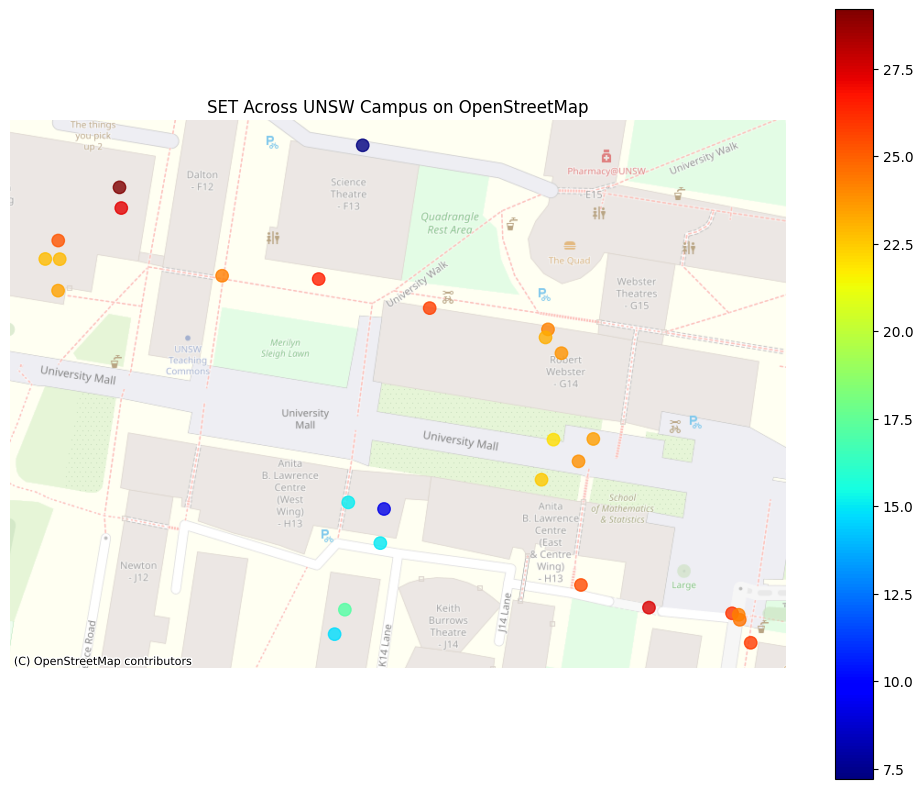

In [13]:
gdf_combined_unsw_resampled = gpd.GeoDataFrame(combined_unsw_resampled, 
                                           geometry=gpd.points_from_xy(combined_unsw_resampled['Longitude'], 
                                                                      combined_unsw_resampled['Latitude']),
                                           crs='EPSG:4326')  # WGS84

#Converts your resampled microclimate DataFrame into a GeoDataFrame, which is needed for spatial operations and plotting.
#geometry=gpd.points_from_xy(...) creates point geometries from each row's longitude and latitude.
#crs='EPSG:4326' sets the coordinate reference system to WGS 84 (latitude/longitude), which is standard for GPS.

gdf_combined_unsw_resampled = gdf_combined_unsw_resampled.to_crs(epsg=3857)

#Reprojects the GeoDataFrame from WGS84 (EPSG:4326) to Web Mercator (EPSG:3857), which is compatible with most online map tile services like OpenStreetMap or Google Maps.

fig, ax = plt.subplots(figsize=(10, 8))

gdf_combined_unsw_resampled.plot(ax=ax, column='SET', cmap='jet', markersize=80, alpha=0.8, legend=True)

#Sets up a plot using matplotlib.
#Plots the spatial points (now in projected coordinates) with color based on SET values, using the 'jet' color scale.
#markersize=80 controls point size, alpha=0.8 gives slight transparency, and legend=True adds a color bar for interpretation.

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.5)

#Adds OpenStreetMap tiles as a basemap layer using Contextily.
#alpha=0.5 ensures the points on top remain clearly visible.

ax.set_axis_off()
plt.title('SET Across UNSW Campus on OpenStreetMap')
plt.tight_layout()
plt.show()

#Removes axes for a cleaner map.
#Adds a title and ensures all plot elements are neatly arranged.

#Convert microclimate data to a spatial GeoDataFrame and reproject to Web Mercator.
#Plot SET values on a map using color-coded points overlaid on an OpenStreetMap basemap for spatial thermal comfort analysis.
#Further observations are noted down in the report provided

In [14]:
!pip install folium

import folium
from folium.plugins import HeatMap
import geopandas as gpd

#Installs and imports Folium, a Python library for creating interactive maps.
#Also imports the HeatMap plugin, used for creating density-based visualizations (heatmaps).
#Imports geopandas just in case spatial data manipulation is needed.

# Assuming gdf_given_file_resampled is already created and has 'Latitude', 'Longitude', and 'SET' columns

heat_data = gdf_combined_unsw_resampled[['Latitude', 'Longitude', 'SET']].dropna()

#Selects only the Latitude, Longitude, and SET columns.
#Drops any rows with missing values to ensure clean input for the heatmap.

m = folium.Map(location=[-33.888, 151.230], zoom_start=13)

#Creates a Folium map centered around UNSW Sydney (or, if you're working on Arizona, you can change this to e.g., [33.4232, -111.9386] for 9th Mill Ave, Tempe, AZ).
#zoom_start=13 sets the initial zoom level.

heat_points = [[row['Latitude'], row['Longitude'], row['SET']] for idx, row in heat_data.iterrows()]

#Converts your heat_data into a list of lists: each sublist contains [latitude, longitude, intensity (SET)].
#This is the format expected by Folium's HeatMap

HeatMap(heat_points).add_to(m)

#Adds the heatmap layer to your Folium map object.
#The brighter/hotter areas indicate higher SET values, highlighting zones of higher thermal stress.

#Display map
m

#Create an interactive heatmap using Folium to visualize spatial distribution of Standard Effective Temperature (SET) across the study area.
#Higher intensity indicates areas of greater thermal discomfort.

C:\Users\sarfr\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedWriter name=4>
  return process_handler(cmd, _system_body)
C:\Users\sarfr\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  return process_handler(cmd, _system_body)
C:\Users\sarfr\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  return process_handler(cmd, _system_body)
C:\Users\sarfr\AppData\Roaming\Python\Python312\site-packages\pandas\core\frame.py:717: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
